### Week 5 notebook - Support Vector Machines, Kernel Trick, and Regularization, Mod C Data Science Capstone Fall 2026
### By Shuqin Ouyang

# Research questions (referenced as RQ1-RQ3 throughout):
- RQ1: which ratios/behaviors signal risk, and in what direction
- RQ2: whether bankruptcy is harder to learn than credit default
- RQ3: whether results are stable (across folds, features, and, from Week 5 on, across different modeling approaches)

# Overall notebook structure:

Tests whether Weeks 1-4 patterns hold under nonlinear models. Part 1 compares three kernels via CV F1: linear (straight boundary), polynomial (coef0=1, fixed-shape curve set by degree), and Gaussian (sklearn's rbf, gamma=1/(2*sigma^2), measures point closeness, bends into any shape). Part 2 sweeps C for the Part 1 winner and plots the margin-vs-fit trade-off (gamma too, if Gaussian wins). One function, evaluate_svm, handles all of it: CV F1, overfitting gap, test F1/precision/recall, support vectors, margin.

Runtime: both datasets subsampled to 1000 train / 250 test rows, linear kernel uses LinearSVC (liblinear) for speed.

In [1]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import f1_score, precision_score, recall_score
from ucimlrepo import fetch_ucirepo

In [2]:
def evaluate_svm(X_train, X_test, y_train, y_test, kernel, C=1, gamma=None, label=""):
    ''' fits + scales one SVM. Reused for kernel comparison, C sweep, and gamma sweep,
    one function covers all three parts. Prints CV F1, train-vs-CV overfitting gap,
    test F1/precision/recall, support vector count (poly/gaussian only), and margin.
    kernel is 'linear', 'poly', or 'rbf' (sklearn's name for the lesson's Gaussian kernel,
    printed as "gaussian" below to match the lesson). '''

    # step 1: scale features (SVMs are distance-based, unscaled features would distort results)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    display_name = 'gaussian' if kernel == 'rbf' else kernel

    # step 2: pick the estimator
    #   linear -> LinearSVC (liblinear), much faster than SVC at this row count, but it
    #   doesn't track individual support vectors the way libsvm-based SVC does
    #   poly/rbf -> SVC, with poly always using coef0=1, degree=3 (sklearn's default,
    #   matches the lesson's c), and gamma added only when passed in (rbf only)
    if kernel == 'linear':
        model = LinearSVC(C=C, max_iter=20000)  # raised from 5000: bankruptcy's C=10/C=100 threw convergence warnings at 5000
    else:
        kernel_settings = {'coef0': 1, 'degree': 3} if kernel == 'poly' else {}
        if gamma is not None:
            kernel_settings['gamma'] = gamma
        model = SVC(kernel=kernel, C=C, **kernel_settings)

    # step 3: fit on the full training set
    model.fit(X_train_scaled, y_train)

    # step 4: cross-validated F1. cross_val_score refits its own copy of model internally
    # on each of the 5 folds regardless of whether model is already fit, so one model
    # object covers both the final fit above and this CV step (n_jobs=-1 runs folds in parallel)
    cv_f1 = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1', n_jobs=-1).mean()

    # step 5: train F1, for the overfitting gap (train F1 minus cv_f1)
    train_f1 = f1_score(y_train, model.predict(X_train_scaled))

    # step 6: test set metrics, on data the model has never seen
    test_predictions = model.predict(X_test_scaled)
    test_f1 = f1_score(y_test, test_predictions)
    test_precision = precision_score(y_test, test_predictions)
    test_recall = recall_score(y_test, test_predictions)

    # step 7: print everything in one readable line
    gamma_text = f" gamma={gamma}" if gamma is not None else ""
    sv_text = f"support vectors={len(model.support_)}" if kernel != 'linear' else "support vectors=n/a (LinearSVC)"
    print(f"{label} {display_name} C={C}{gamma_text}: "
          f"CV F1={cv_f1:.3f}, train F1={train_f1:.3f} (gap={train_f1 - cv_f1:.3f}), "
          f"test F1={test_f1:.3f}, precision={test_precision:.3f}, recall={test_recall:.3f}, {sv_text}")

    # step 8: margin (linear only) -- margin=1/||w|| needs a single weight vector w
    # (model.coef_), which only exists for a literal straight-line boundary. Poly/gaussian
    # push data into a different, often much higher-dimensional space, so the "flat
    # hyperplane" lives there, not in the original feature space -- no coef_, no simple
    # margin formula (sklearn's SVC raises an error if you try .coef_ on a non-linear kernel).
    # gamma (gaussian only) -- gamma is a term inside the gaussian formula itself,
    # K(x,z)=exp(-gamma*||x-z||^2); it doesn't appear in the linear or polynomial formulas
    # at all, so it's only meaningful to set when kernel='rbf'.
    if kernel == 'linear':
        margin = 1 / np.linalg.norm(model.coef_)
        print(f"  margin={margin:.4f}")

    return cv_f1


# Student dataset analysis starts here:

Dataset 1 background quick overview:

The dataset 1 used is the Taiwanese Bankruptcy Prediction dataset from UCI, link as https://archive.ics.uci.edu/dataset/572/taiwanese+bankruptcy+prediction.
It contains company financial indicators and a binary outcome for bankruptcy.

In [3]:
data_bankruptcy = fetch_ucirepo(id=572)
df_bankruptcy = pd.concat([data_bankruptcy.data.features.copy(), data_bankruptcy.data.targets.copy()], axis=1)
df_bankruptcy.columns = df_bankruptcy.columns.str.strip()
target_bankrupt = 'Bankrupt?'
X_bankrupt = df_bankruptcy.drop(columns=[target_bankrupt]).dropna()
y_bankrupt = df_bankruptcy.loc[X_bankrupt.index, target_bankrupt]
print("Rows available after dropping missing values:", len(X_bankrupt))

# subsample for speed, SVC training time grows faster than linearly with row count
Xtr_bankrupt, Xte_bankrupt, ytr_bankrupt, yte_bankrupt = train_test_split(
    X_bankrupt, y_bankrupt, train_size=1000, test_size=250, stratify=y_bankrupt, random_state=42)

Rows available after dropping missing values: 6819


In [4]:
# Part 1: kernel comparison
for k in ['linear', 'poly', 'rbf']:
    evaluate_svm(Xtr_bankrupt, Xte_bankrupt, ytr_bankrupt, yte_bankrupt, k, label="Bankruptcy")

Bankruptcy linear C=1: CV F1=0.303, train F1=0.717 (gap=0.414), test F1=0.500, precision=0.500, recall=0.500, support vectors=n/a (LinearSVC)
  margin=0.4425
Bankruptcy poly C=1: CV F1=0.114, train F1=0.769 (gap=0.655), test F1=0.154, precision=0.200, recall=0.125, support vectors=114
Bankruptcy gaussian C=1: CV F1=0.000, train F1=0.316 (gap=0.316), test F1=0.000, precision=0.000, recall=0.000, support vectors=191


c:\Users\ouyan\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Student markdown:

Linear wins clearly (CV F1=0.303) over poly (0.114) and gaussian (0.000, predicted no bankruptcies at all). Matches Week 4, where L1 logistic regression already found this dataset's signal to be mostly linear, no gain from letting the boundary curve. Gaussian's complete failure is likely the ~3% bankruptcy base rate combined with only 1000 subsampled rows, not enough minority-class signal for a closeness-based kernel to latch onto at default settings.

best_kernel_bankrupt = 'linear'

Bankruptcy linear C=0.01: CV F1=0.195, train F1=0.316 (gap=0.121), test F1=0.000, precision=0.000, recall=0.000, support vectors=n/a (LinearSVC)
  margin=3.6850
Bankruptcy linear C=0.1: CV F1=0.233, train F1=0.476 (gap=0.243), test F1=0.333, precision=0.500, recall=0.250, support vectors=n/a (LinearSVC)
  margin=1.2027
Bankruptcy linear C=1: CV F1=0.303, train F1=0.717 (gap=0.414), test F1=0.500, precision=0.500, recall=0.500, support vectors=n/a (LinearSVC)
  margin=0.4425
Bankruptcy linear C=10: CV F1=0.267, train F1=0.741 (gap=0.474), test F1=0.429, precision=0.500, recall=0.375, support vectors=n/a (LinearSVC)
  margin=0.1500
Bankruptcy linear C=100: CV F1=0.245, train F1=0.786 (gap=0.541), test F1=0.588, precision=0.556, recall=0.625, support vectors=n/a (LinearSVC)
  margin=0.0516


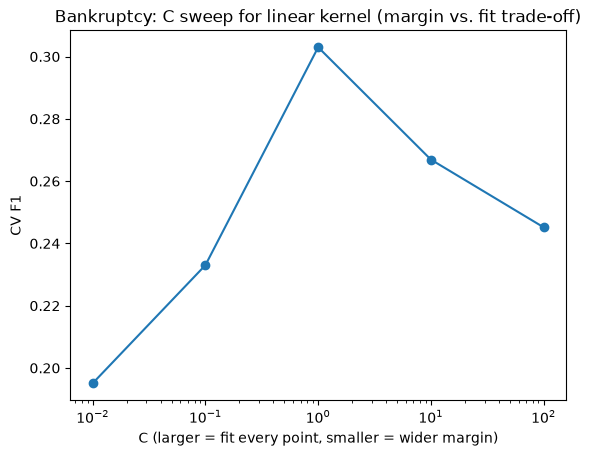

In [5]:
# Part 2: C sweep + margin-vs-fit plot (reuses the same function); adds gamma sweep if gaussian won Part 1
best_kernel_bankrupt = 'linear'  # from Part 1: linear wins clearly
C_values = [0.01, 0.1, 1, 10, 100]
display_name_bankrupt = 'gaussian' if best_kernel_bankrupt == 'rbf' else best_kernel_bankrupt

f1s = [evaluate_svm(Xtr_bankrupt, Xte_bankrupt, ytr_bankrupt, yte_bankrupt, best_kernel_bankrupt, C=c, label="Bankruptcy") for c in C_values]
plt.plot(C_values, f1s, marker='o')
plt.xscale('log')  # C jumps by 10x each step, log scale spaces those evenly instead of crushing them to the left
plt.xlabel('C (larger = fit every point, smaller = wider margin)'); plt.ylabel('CV F1')
plt.title(f'Bankruptcy: C sweep for {display_name_bankrupt} kernel (margin vs. fit trade-off)'); plt.show()

if best_kernel_bankrupt == 'rbf':
    for g in [0.01, 0.1, 1]:
        evaluate_svm(Xtr_bankrupt, Xte_bankrupt, ytr_bankrupt, yte_bankrupt, 'rbf', C=1, gamma=g, label="Bankruptcy")

Student markdown:

CV F1 peaks at C=1 (0.303), now confirmed converged after raising max_iter to 20000. C=1 is the pick: best CV F1, moderate margin (0.443), gap still reasonable (0.414) next to C=10/C=100's larger gaps.

Student markdown:

Conclusion (Bankruptcy):

| C | CV F1 | gap | margin |
|---|---|---|---|
| 0.01 | 0.195 | 0.121 | 3.685 |
| 0.1 | 0.233 | 0.243 | 1.203 |
| 1 | 0.303 | 0.414 | 0.443 |
| 10 | 0.267 | 0.474 | 0.150 |
| 100 | 0.245 | 0.541 | 0.052 |

Part 1: linear 0.303, poly 0.114, gaussian 0.000. Final model: linear, C=1, test F1=0.500, precision=0.500, recall=0.500.

**Overfitting:** train F1 vs. 5-fold CV F1, same design as Week 4's check_overfitting_f1, compared across all 5 C values rather than trusting a single fit. The gap grows steadily with C (0.121 to 0.541), exactly as expected: larger C forces the model to fit individual training points more aggressively (train F1 climbs from 0.316 to 0.786), but CV F1 doesn't follow anywhere near as far, it actually peaks at C=1 and falls off on either side. This is why CV F1, not train F1, has to be the number that picks C, chasing train F1 alone would have landed on C=100, the most overfit option in the sweep. Caveat: this runs on a 1000-row subsample (250 test) for SVC runtime reasons, smaller than Week 4's full ~6,800 rows, so these numbers are noisier than Week 4's and should be read as directional rather than an exact replication at the same scale.

**Metrics and hyperparameter tuning:** F1 is the main metric, same choice as Week 4, since accuracy would be misleading given bankruptcy's roughly 3% positive rate, a model that just predicts "not bankrupt" every time would still score over 96% accuracy while being useless. C is the regularization knob: larger C prioritizes fitting every training point correctly at the cost of a narrower margin, smaller C accepts more training error in exchange for a wider, more generalizable margin, directly the trade-off the lesson describes. CV F1 peaked at C=1, so that's the chosen value. Gamma was never tuned here, since gaussian lost Part 1 (CV F1=0.000), the code's gamma sweep only runs if best_kernel == 'rbf':, so that branch never executed for bankruptcy.

**Margin:** shrinks steadily as C grows (3.685 at C=0.01 down to 0.052 at C=100, both read directly from the Part 2 printout above), directly mirroring the overfitting gap's rise in the opposite direction, the same trade-off viewed from two angles. Margin is computed as 1/||w||, so it moves opposite to the size of the weight vector: larger C tells the model to prioritize fitting every training point over keeping a wide buffer, which pushes ||w|| up and margin down, exactly why C=0.01's cautious, wide-margin model (3.685) sits at one end and C=100's tightly-fit, narrow-margin model (0.052) sits at the other. That directly explains the gap column too, more fitting to the training data (larger C, smaller margin) is the same thing as a higher train F1 with less room left for new data to land correctly, which is what overfitting is. At the chosen C=1, margin=0.443 sits solidly in the middle, neither the widest, most conservative option nor the narrowest, most overfit one, consistent with C=1 being the balanced pick rather than an extreme.

**Expected vs. unexpected:** linear beating poly and gaussian matched Week 4, where L1-penalized logistic regression, also a linear model, already worked reasonably well on this dataset. That agreement matters more than it might first look: Week 4 and Week 5 are two structurally different algorithms (logistic regression vs. SVM) independently asking the same underlying question, does bankruptcy actually need a curved decision boundary, or is a straight line enough? Both landed on the same answer, a straight line is enough, which is stronger evidence than either result alone would be, and directly supports RQ3 below. Going in, though, I actually expected the opposite, bankruptcy is 95 financial ratios, and I assumed a more complex model would be needed to capture that. Worth reconciling this against Week 1, which found Net Income to Total Assets alone was genuinely nonlinear (R squared jumped from 0.002 for a linear fit to 0.602 for a degree-2 polynomial). That's not actually a contradiction: a linear kernel is a linear combination across all 95 features at once, not a straight-line fit to any single feature, so even if one feature curves on its own, combining enough features linearly can still trace a boundary that separates classes well, especially given Week 4's finding that many of these ratios are redundant with each other (high VIF, several near-duplicate pairs), the model has plenty of linear "levers" to combine rather than needing any one feature's own curve. Gaussian's complete failure (F1=0.000) was the more genuinely unexpected result in its severity, with roughly 3% positives in a 1000-row subsample (about 30 positive rows), a closeness-based kernel likely doesn't have enough minority-class neighbors nearby to work with at default settings, worth retesting with a larger sample or explicit gamma tuning before ruling gaussian out for good.

**EDA usefulness:** less directly useful here than in earlier weeks. VIF, PCA, and correlation analysis all mapped cleanly onto OLS coefficients and R squared back in Weeks 1-4, but SVM's kernel-based margin, especially for poly and gaussian, doesn't translate back to individual feature relationships the same way, there's no simple coefficient table to inspect afterward. Part 1's empirical kernel comparison itself did more work here than prior EDA for actually deciding model structure. That said, Week 1's single-feature polynomial fit was still a useful prior expectation to test the multivariate result against, which is exactly the tension discussed above, so EDA wasn't wasted, just less load-bearing than in a linear-regression-based week.

**Sources:** this week's lesson content, plus GeeksforGeeks, "Major Kernel Functions in Support Vector Machine (SVM)," https://www.geeksforgeeks.org/machine-learning/major-kernel-functions-in-support-vector-machine-svm/, for the kernel formulas and characteristics referenced above.

**RQ tie-in:** supports RQ1, bankruptcy's risk signal is linear, a nonlinear model finds no new signal beyond what Week 4's logistic regression already found. Supports RQ3, this linear-favoring result now holds across two independent, structurally different model families (Week 4's logistic regression and Week 5's SVM kernel comparison), which is meaningfully stronger evidence of stability than either result alone. RQ2 needs credit card's result alongside this one, addressed in the final summary below.

Dataset 2 background quick overview:

The dataset 2 used is the Default of Credit Card Clients dataset from UCI, link as https://archive.ics.uci.edu/dataset/350/default+of+credit+card+clients.

It contains demographic information, credit limits, repayment history, bill statements, and previous payment records for Taiwanese credit card clients, along with a binary outcome indicating whether the client defaulted on the next payment.

In [6]:
data_credit = fetch_ucirepo(id=350)
df_credit = pd.concat([data_credit.data.features.copy(), data_credit.data.targets.copy()], axis=1)
df_credit = df_credit.rename(columns={
    "Y": "default_next_month", "X1": "credit_limit", "X2": "gender", "X3": "education",
    "X4": "marital_status", "X5": "age",
    "X6": "repay_2005_sep", "X7": "repay_2005_aug", "X8": "repay_2005_jul",
    "X9": "repay_2005_jun", "X10": "repay_2005_may", "X11": "repay_2005_apr",
    "X12": "bill_2005_sep", "X13": "bill_2005_aug", "X14": "bill_2005_jul",
    "X15": "bill_2005_jun", "X16": "bill_2005_may", "X17": "bill_2005_apr",
    "X18": "pay_2005_sep", "X19": "pay_2005_aug", "X20": "pay_2005_jul",
    "X21": "pay_2005_jun", "X22": "pay_2005_may", "X23": "pay_2005_apr"
})
target_credit = 'default_next_month'
X_credit = df_credit.drop(columns=[target_credit]).dropna()
y_credit = df_credit.loc[X_credit.index, target_credit]
print("Rows available after dropping missing values:", len(X_credit))

# subsample for speed, matches bankruptcy's size so the two are on comparable footing
Xtr_credit, Xte_credit, ytr_credit, yte_credit = train_test_split(
    X_credit, y_credit, train_size=1000, test_size=250, stratify=y_credit, random_state=42)

Rows available after dropping missing values: 30000


In [7]:
# Part 1: kernel comparison
for k in ['linear', 'poly', 'rbf']:
    evaluate_svm(Xtr_credit, Xte_credit, ytr_credit, yte_credit, k, label="Credit card")

Credit card linear C=1: CV F1=0.243, train F1=0.232 (gap=-0.011), test F1=0.103, precision=1.000, recall=0.055, support vectors=n/a (LinearSVC)
  margin=3.2188
Credit card poly C=1: CV F1=0.321, train F1=0.517 (gap=0.196), test F1=0.427, precision=0.800, recall=0.291, support vectors=485
Credit card gaussian C=1: CV F1=0.300, train F1=0.411 (gap=0.110), test F1=0.290, precision=0.714, recall=0.182, support vectors=546


Student markdown:

Poly wins (CV F1=0.321), narrowly ahead of gaussian (0.300), both clearly ahead of linear (0.243). Opposite of bankruptcy, where linear won outright, here some nonlinearity genuinely helps.

best_kernel_credit = 'poly'

Credit card poly C=0.01: CV F1=0.035, train F1=0.070 (gap=0.035), test F1=0.036, precision=1.000, recall=0.018, support vectors=485
Credit card poly C=0.1: CV F1=0.280, train F1=0.367 (gap=0.088), test F1=0.273, precision=0.818, recall=0.164, support vectors=482
Credit card poly C=1: CV F1=0.321, train F1=0.517 (gap=0.196), test F1=0.427, precision=0.800, recall=0.291, support vectors=485
Credit card poly C=10: CV F1=0.333, train F1=0.736 (gap=0.404), test F1=0.421, precision=0.500, recall=0.364, support vectors=476
Credit card poly C=100: CV F1=0.278, train F1=0.872 (gap=0.594), test F1=0.380, precision=0.422, recall=0.345, support vectors=466


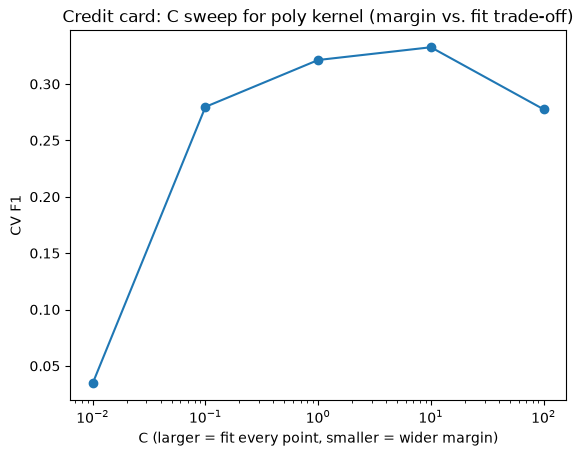

In [8]:
# Part 2: C sweep + margin-vs-fit plot; adds gamma sweep if gaussian won Part 1
best_kernel_credit = 'poly'  # from Part 1: poly wins
C_values = [0.01, 0.1, 1, 10, 100]
display_name_credit = 'gaussian' if best_kernel_credit == 'rbf' else best_kernel_credit

f1s = [evaluate_svm(Xtr_credit, Xte_credit, ytr_credit, yte_credit, best_kernel_credit, C=c, label="Credit card") for c in C_values]
plt.plot(C_values, f1s, marker='o')
plt.xscale('log'); plt.xlabel('C (larger = fit every point, smaller = wider margin)'); plt.ylabel('CV F1')
plt.title(f'Credit card: C sweep for {display_name_credit} kernel (margin vs. fit trade-off)'); plt.show()

if best_kernel_credit == 'rbf':
    for g in [0.01, 0.1, 1]:
        evaluate_svm(Xtr_credit, Xte_credit, ytr_credit, yte_credit, 'rbf', C=1, gamma=g, label="Credit card")

Student markdown:

CV F1 peaks at C=10 (0.333), just ahead of C=1 (0.321), but C=10's gap is more than double (0.404 vs. 0.196) and precision much worse (0.500 vs. 0.800). Picking C=1: near-best CV F1, best precision, smallest gap among the top performers.

Student markdown:

Conclusion (Credit card):

| C | CV F1 | gap | precision |
|---|---|---|---|
| 0.01 | 0.035 | 0.035 | 1.000 |
| 0.1 | 0.280 | 0.088 | 0.818 |
| 1 | 0.321 | 0.196 | 0.800 |
| 10 | 0.333 | 0.404 | 0.500 |
| 100 | 0.278 | 0.594 | 0.422 |

Part 1: poly 0.321, gaussian 0.300, linear 0.243. Final model: poly, C=1, test F1=0.427, precision=0.800, recall=0.291, support vectors=48.5% of training rows.

**Overfitting:** same design as bankruptcy, train F1 vs. 5-fold CV F1 across the same 5 C values. The gap grows sharply and steadily with C (0.035 to 0.594), train F1 climbing from 0.070 to 0.872 while CV F1 actually peaks at C=10 and falls off either side. The interesting decision is what this means for the C choice itself: C=10 has the single highest CV F1 (0.333), edging out C=1's 0.321, but its gap is more than double (0.404 vs. 0.196) and its precision is much worse (0.500 vs. 0.800). Picking C=1 instead of the raw-best C=10 is a direct, real example of the lesson's margin-vs-fit trade-off in practice, the top CV F1 number alone would have picked the more overfit, less precise model.

**Metrics and hyperparameter tuning:** F1 is the main metric again, with precision (0.800) and recall (0.291) both reported since they tell very different stories here, when this model predicts default it's right 80% of the time, but it only catches about 29% of the people who actually default. C=1 was chosen over C=10 by weighing CV F1, the overfitting gap, and precision together rather than optimizing CV F1 alone. Gamma was not tuned for credit card either, gaussian's CV F1 (0.300) came close to poly's (0.321) but did not win Part 1, so the code's gamma-sweep branch never executed. Given how close gaussian finished, it's plausible gamma tuning could flip that result, worth testing directly in follow-up work rather than treating poly's win as fully decisive.

**Margin:** not reported here, unlike bankruptcy's table. The simple margin=1/||w|| formula only applies to the linear kernel, where a single weight vector defines the boundary; poly pushes the data into a higher-dimensional space where that flat hyperplane no longer corresponds to one simple weight vector in the original feature space, so .coef_ isn't available and there's no comparable margin number to report for this dataset's winning model.

**Expected vs. unexpected:** going in, before seeing Part 1's results, the natural guess was that either linear or gaussian would win, not poly specifically. Linear felt like the safe bet since Week 4's logistic regression, also a linear model, already produced a real result on this same dataset (test F1=0.351). Gaussian felt like the other likely winner since it's the most flexible of the three kernels, if the data needed some kind of curve at all, gaussian seemed like the obvious catch-all that should win by default. Poly winning instead, a kernel with a fixed, specific-shaped curve rather than gaussian's near-unlimited flexibility, suggests credit card's true decision boundary has real but moderate curvature to it, not the wild, irregular shape gaussian is built for. The bigger surprise, though, was the support vector count: I assumed credit card, being far less imbalanced than bankruptcy (roughly 22% defaults vs. bankruptcy's 3%, per Week 4 and UCI's documentation), would be the easier dataset to cleanly separate. Instead, support vectors stayed high and essentially flat across every C tested, roughly half the training rows, meaning the two classes overlap substantially rather than separating cleanly. So imbalance and class overlap turned out to be two separate axes of difficulty that don't move together, credit card is more balanced but harder to cleanly separate, the opposite of what I expected. On the positive side, poly's test F1 (0.427) beats Week 4's logistic regression result on this same dataset (0.351), with better precision (0.800 vs. 0.691) and recall (0.291 vs. 0.235) too, real evidence that credit card default carries a genuine nonlinear component Week 4's linear model was missing.

**EDA usefulness:** similar to bankruptcy, Part 1's empirical kernel comparison did more of the real work here than prior EDA, SVM's margin doesn't map back to individual feature relationships the way Week 4's logistic regression coefficients did. That said, Week 4's finding that credit card's linear signal was "thin but consistent" (L1 kept 22 of 23 features, with very little fold-to-fold instability) did set a reasonable expectation that this dataset's true structure might need more than a straight line to fully capture, which is exactly what played out here once poly was tested.

**Sources:** this week's lesson content, plus GeeksforGeeks, "Major Kernel Functions in Support Vector Machine (SVM)," https://www.geeksforgeeks.org/machine-learning/major-kernel-functions-in-support-vector-machine-svm/.

**RQ tie-in:** supports RQ1, credit card carries real nonlinear signal that Week 4's linear model missed, the opposite conclusion from bankruptcy. Complicates RQ2, credit card isn't simply "harder" than bankruptcy in one single sense, it's less imbalanced but more overlapping between classes, two different kinds of difficulty that don't move together, so the difficulty gap looks less like "credit card is just harder" and more like "credit card needed a different kind of model." Updates RQ3, unlike bankruptcy where Week 4 and Week 5 agree, credit card's two weeks genuinely disagree on whether a linear model alone is sufficient, a real instability worth carrying into Week 6's random forest comparison as a specific thing to check.

Summary:

| Dataset | Best kernel | Final C | Test F1 | Precision | Recall | Gap |
|---|---|---|---|---|---|---|
| Bankruptcy | linear | 1 | 0.500 | 0.500 | 0.500 | 0.414 |
| Credit card | poly | 1 | 0.427 | 0.800 | 0.291 | 0.196 |

Bankruptcy: linear wins outright, matches Week 4's logistic regression, no benefit from nonlinearity. Credit card: poly wins, beats Week 4's logistic regression (test F1 0.351), real nonlinear signal Week 4 missed. Gamma untested for both, gaussian never won Part 1 in either dataset.

Both datasets landed on the same final C=1, but this is unlikely to be a meaningful signal on its own. Week 4 saw the same pattern, both datasets' logistic regression tuning picked the identical C=0.359 there too, and the conclusion at the time was that a coarse, fixed grid of candidate values (only 5 here, 0.01/0.1/1/10/100) can easily produce a coincidental match between two genuinely different problems, not real evidence they need identical regularization. The same caution applies here, especially since the two datasets picked C=1 for different kernels (linear vs. poly), so "C=1" doesn't even mean the same thing mechanically in each case, it's tuned relative to a different kind of decision boundary in each dataset. The meaningful structural difference between the two datasets isn't the matching C, it's the different kernel that won Part 1 (linear vs. poly), that's the real, comparable finding for RQ1 and RQ3 below.

**RQ tie-in:**
- RQ1 (risk signals): bankruptcy's signal is linear only, unchanged from Week 4. Credit card has a genuine nonlinear component.
- RQ2 (difficulty): bankruptcy still wins on raw F1, but credit card's gap narrows with the right kernel. Imbalance (~3% vs. ~22%) and class overlap are separate axes, credit card is more balanced but more overlapping, its support vectors stayed near half the training rows across every C tested.
- RQ3 (stability): bankruptcy is stable across Week 4 and Week 5 (both favor linear). Credit card is not, the two weeks disagree on whether linear is sufficient, worth checking again in Week 6's random forest.

**Caveat:** all Week 5 numbers use a 1000-row subsample (250 test) vs. Week 4's full datasets, read the comparison as directional, not an exact replication at Week 4's scale.